# CS3012E Artificial Intelligence – Course Project
## Imbalanced Text Classification Study
**Dataset:** Disaster Tweets (Kaggle)  
**Models:** Logistic Regression · Random Forest · Neural Network (MLP)  
**Sections:** Part A (no imbalance handling) · Part B (with imbalance handling)


## 1. Imports & Setup

In [36]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, auc, classification_report
)

# Imbalance handling
from sklearn.utils import resample

# Reproducibility
SEED = 42
np.random.seed(SEED)

print('All imports successful.')
print('sklearn version:', __import__('sklearn').__version__)


All imports successful.
sklearn version: 1.6.1


## 2. Dataset Loading
Download `train.csv` from [Kaggle Disaster Tweets](https://www.kaggle.com/datasets/vstepanenko/disaster-tweets/data) and place it in the same directory as this notebook (or update the path below).

In [37]:
# # ── Update this path if your file is elsewhere ──
# DATA_PATH = 'tweets.csv'

df = pd.read_csv("tweets.csv")
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()


Shape: (11370, 5)
Columns: ['id', 'keyword', 'location', 'text', 'target']


,id,keyword,location,text,target
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0


## 3. Exploratory Data Analysis

In [38]:
print('=== Basic Info ===')
print(df.info())
print('\n=== Missing values ===')
print(df.isnull().sum())
print('\n=== Class Distribution ===')
print(df['target'].value_counts())
print('\nClass ratio (imbalance):',
      round(df['target'].value_counts()[0] / df['target'].value_counts()[1], 3))


=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11370 entries, 0 to 11369
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        11370 non-null  int64 
 1   keyword   11370 non-null  object
 2   location  7952 non-null   object
 3   text      11370 non-null  object
 4   target    11370 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 444.3+ KB
None

=== Missing values ===
id             0
keyword        0
location    3418
text           0
target         0
dtype: int64

=== Class Distribution ===
target
0    9256
1    2114
Name: count, dtype: int64

Class ratio (imbalance): 4.378


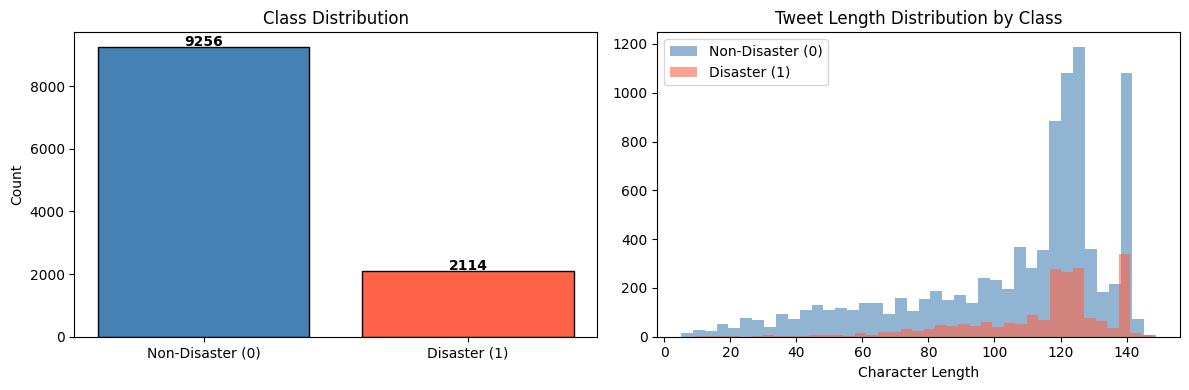

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution bar
counts = df['target'].value_counts().sort_index()
axes[0].bar(['Non-Disaster (0)', 'Disaster (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Tweet length distribution
df['text_len'] = df['text'].fillna('').apply(len)

axes[1].hist(df[df['target'] == 0]['text_len'],
             bins=40, alpha=0.6, label='Non-Disaster (0)', color='steelblue')

axes[1].hist(df[df['target'] == 1]['text_len'],
             bins=40, alpha=0.6, label='Disaster (1)', color='tomato')

axes[1].set_title('Tweet Length Distribution by Class')
axes[1].set_xlabel('Character Length')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Text Preprocessing
- Fill missing `text` values
- Lowercase, strip URLs, mentions, hashtags, extra spaces
- TF-IDF vectorization (applied inside pipelines to avoid data leakage)


In [40]:
import re

def clean_text(text):
    """Basic text cleaning for tweets."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'@\w+', '', text)                     # remove mentions
    text = re.sub(r'#(\w+)', r'\1', text)               # strip hashtag symbol
    text = re.sub(r'[^a-z0-9\s]', ' ', text)            # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()             # collapse whitespace
    return text

df['clean_text'] = df['text'].fillna('').apply(clean_text)
print('Sample cleaned tweets:')
for i in range(3):
    print(f'  Original : {df["text"].iloc[i]}')
    print(f'  Cleaned  : {df["clean_text"].iloc[i]}')
    print()


Sample cleaned tweets:
  Original : Communal violence in Bhainsa, Telangana. "Stones were pelted on Muslims' houses and some houses and vehicles were set ablaze…
  Cleaned  : communal violence in bhainsa telangana stones were pelted on muslims houses and some houses and vehicles were set ablaze

  Original : Telangana: Section 144 has been imposed in Bhainsa from January 13 to 15, after clash erupted between two groups on January 12. Po…
  Cleaned  : telangana section 144 has been imposed in bhainsa from january 13 to 15 after clash erupted between two groups on january 12 po

  Original : Arsonist sets cars ablaze at dealership https://t.co/gOQvyJbpVI
  Cleaned  : arsonist sets cars ablaze at dealership



## 5. Train / Test Split

In [41]:
X = df['clean_text'].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train size : {len(X_train)}')
print(f'Test size  : {len(X_test)}')
print(f'Train class distribution: {np.bincount(y_train)}')
print(f'Test  class distribution: {np.bincount(y_test)}')


Train size : 9096
Test size  : 2274
Train class distribution: [7405 1691]
Test  class distribution: [1851  423]


## 6. Evaluation Helper Functions

In [42]:
def evaluate_model(name, y_true, y_pred, y_proba, label=''):
    """Print metrics and return a result dict."""
    acc  = accuracy_score(y_true, y_pred)
    prec_w = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec_w  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_mac = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_wt  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    roc_auc = roc_auc_score(y_true, y_proba)

    precision_c, recall_c, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recall_c, precision_c)

    tag = f'{name}' + (f' [{label}]' if label else '')
    print(f'\n{'='*60}')
    print(f' {tag}')
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred,
          target_names=['Non-Disaster', 'Disaster'], zero_division=0))
    print(f'  Accuracy       : {acc:.4f}')
    print(f'  F1 Macro       : {f1_mac:.4f}')
    print(f'  F1 Weighted    : {f1_wt:.4f}')
    print(f'  ROC-AUC        : {roc_auc:.4f}')
    print(f'  PR-AUC         : {pr_auc:.4f}')

    return {
        'Model': tag, 'Accuracy': acc,
        'Precision (W)': prec_w, 'Recall (W)': rec_w,
        'F1 Macro': f1_mac, 'F1 Weighted': f1_wt,
        'ROC-AUC': roc_auc, 'PR-AUC': pr_auc,
        'y_true': y_true, 'y_pred': y_pred, 'y_proba': y_proba
    }


def plot_confusion_matrix(results, title_suffix=''):
    """Plot confusion matrices for a list of result dicts."""
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1:
        axes = [axes]
    for ax, res in zip(axes, results):
        cm = confusion_matrix(res['y_true'], res['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Non-Dis', 'Disaster'],
                    yticklabels=['Non-Dis', 'Disaster'])
        ax.set_title(res['Model'])
        ax.set_ylabel('True')
        ax.set_xlabel('Predicted')
    plt.suptitle(f'Confusion Matrices {title_suffix}', y=1.02, fontsize=13)
    plt.tight_layout()
    safe = title_suffix.replace(' ', '_').replace('/', '_')
    plt.savefig(f'cm_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_roc_pr(results, title_suffix=''):
    """Plot ROC and PR curves for a list of result dicts."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    for res in results:
        fpr, tpr, _ = roc_curve(res['y_true'], res['y_proba'])
        ax1.plot(fpr, tpr, label=f"{res['Model']} (AUC={res['ROC-AUC']:.3f})")

        p, r, _ = precision_recall_curve(res['y_true'], res['y_proba'])
        ax2.plot(r, p, label=f"{res['Model']} (AUC={res['PR-AUC']:.3f})")

    ax1.plot([0,1],[0,1],'k--'); ax1.set_title('ROC Curves')
    ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR'); ax1.legend(fontsize=8)

    ax2.set_title('Precision-Recall Curves')
    ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
    ax2.legend(fontsize=8)

    plt.suptitle(f'ROC & PR Curves {title_suffix}', fontsize=13)
    plt.tight_layout()
    safe = title_suffix.replace(' ', '_').replace('/', '_')
    plt.savefig(f'roc_pr_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


---
# PART A – Without Imbalance Handling
Train all three models on the raw (imbalanced) dataset.


### Part A – Model 1: Logistic Regression

In [43]:
# TF-IDF + Logistic Regression pipeline
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2
    )),
    ('clf', LogisticRegression(
        penalty='l2',       # Tunable: 'l1' / 'l2'
        C=1.0,              # Regularization strength (inverse)
        solver='lbfgs',     # Tunable: 'saga' for l1, 'lbfgs' for l2
        max_iter=1000,
        random_state=SEED
    ))
])

lr_pipeline.fit(X_train, y_train)

# Default threshold (0.5)
y_pred_lr_a  = lr_pipeline.predict(X_test)
y_proba_lr_a = lr_pipeline.predict_proba(X_test)[:, 1]

res_lr_a = evaluate_model('Logistic Regression', y_test, y_pred_lr_a,
                           y_proba_lr_a, label='Part A')



 Logistic Regression [Part A]
              precision    recall  f1-score   support

Non-Disaster       0.87      0.99      0.93      1851
    Disaster       0.88      0.37      0.52       423

    accuracy                           0.87      2274
   macro avg       0.87      0.68      0.72      2274
weighted avg       0.87      0.87      0.85      2274

  Accuracy       : 0.8729
  F1 Macro       : 0.7230
  F1 Weighted    : 0.8510
  ROC-AUC        : 0.9145
  PR-AUC         : 0.7644


### Part A – Model 2: Random Forest

In [44]:
from sklearn.pipeline import Pipeline as SKPipeline

# Shared vectorizer (fit once for RF to avoid re-fitting)
tfidf_vec = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2
    )),
    ('clf', RandomForestClassifier(
        n_estimators=200,       # Tunable: number of trees
        max_depth=None,         # Tunable: max tree depth
        min_samples_split=2,    # Tunable
        min_samples_leaf=1,     # Tunable
        n_jobs=-1,
        random_state=SEED
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf_a  = rf_pipeline.predict(X_test)
y_proba_rf_a = rf_pipeline.predict_proba(X_test)[:, 1]

res_rf_a = evaluate_model('Random Forest', y_test, y_pred_rf_a,
                           y_proba_rf_a, label='Part A')



 Random Forest [Part A]
              precision    recall  f1-score   support

Non-Disaster       0.89      0.98      0.93      1851
    Disaster       0.85      0.45      0.59       423

    accuracy                           0.88      2274
   macro avg       0.87      0.72      0.76      2274
weighted avg       0.88      0.88      0.87      2274

  Accuracy       : 0.8835
  F1 Macro       : 0.7619
  F1 Weighted    : 0.8687
  ROC-AUC        : 0.9089
  PR-AUC         : 0.7605


### Part A – Model 3: Neural Network (Fixed Architecture)
Architecture: Input → 64 → 32 → 16 → Output (sigmoid)  
`MLPClassifier` uses `logistic` (sigmoid) on the output layer automatically for binary classification.  
Hidden layer activation, optimizer, learning rate, epochs (max_iter), dropout (alpha L2), and batch size are tunable.

In [45]:
nn_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2
    )),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(64, 32, 16),   # Fixed architecture
        activation='relu',                  # Tunable: relu/tanh/logistic
        solver='adam',                      # Tunable: sgd/adam/rmsprop(lbfgs)
        learning_rate_init=0.001,           # Tunable learning rate
        max_iter=50,                        # Tunable epochs
        batch_size=64,                      # Tunable batch size
        alpha=1e-4,                         # L2 regularization strength (tunable)
        early_stopping=True,
        validation_fraction=0.1,
        random_state=SEED,
        verbose=False
    ))
])

print('Training Neural Network (Part A)...')
nn_pipeline.fit(X_train, y_train)
print('Training complete.')

y_pred_nn_a  = nn_pipeline.predict(X_test)
y_proba_nn_a = nn_pipeline.predict_proba(X_test)[:, 1]

res_nn_a = evaluate_model('Neural Network', y_test, y_pred_nn_a,
                           y_proba_nn_a, label='Part A')


Training Neural Network (Part A)...
Training complete.

 Neural Network [Part A]
              precision    recall  f1-score   support

Non-Disaster       0.91      0.96      0.94      1851
    Disaster       0.77      0.60      0.67       423

    accuracy                           0.89      2274
   macro avg       0.84      0.78      0.81      2274
weighted avg       0.89      0.89      0.89      2274

  Accuracy       : 0.8923
  F1 Macro       : 0.8050
  F1 Weighted    : 0.8869
  ROC-AUC        : 0.9061
  PR-AUC         : 0.7596


### Part A – Confusion Matrices & Curves

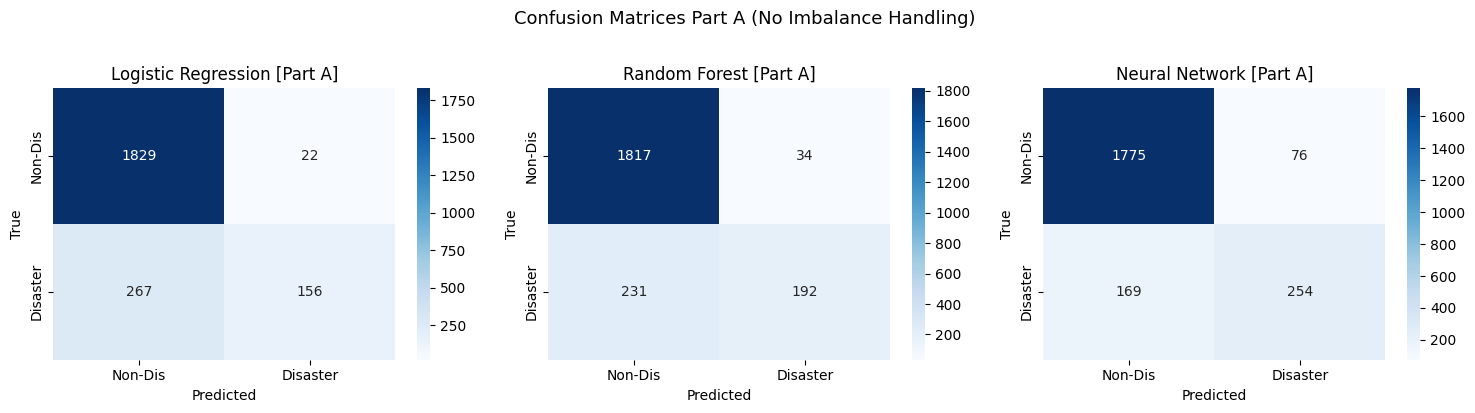

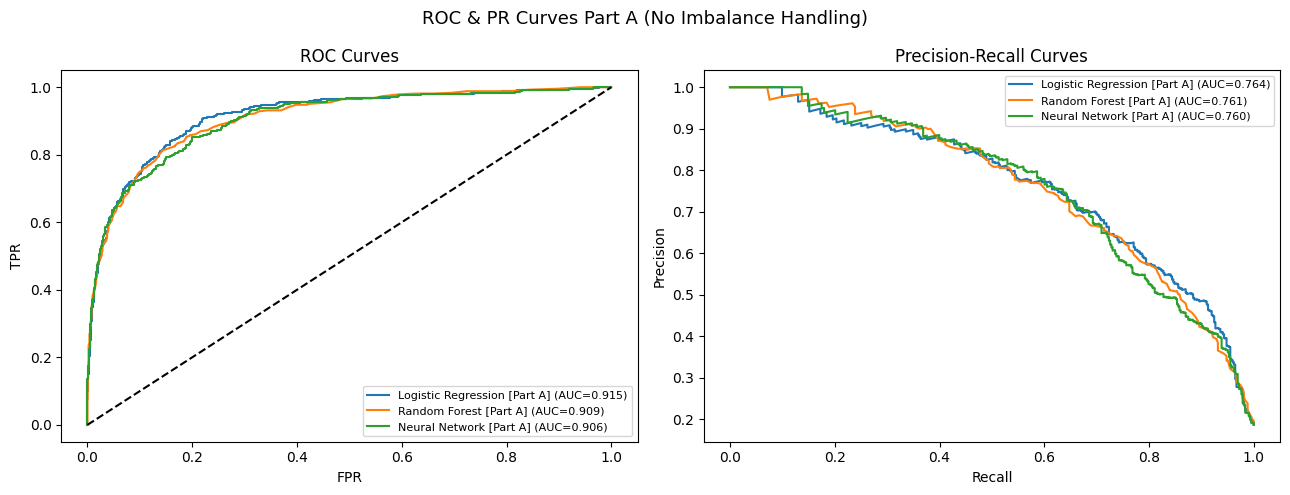

In [46]:
results_a = [res_lr_a, res_rf_a, res_nn_a]
plot_confusion_matrix(results_a, title_suffix='Part A (No Imbalance Handling)')
plot_roc_pr(results_a, title_suffix='Part A (No Imbalance Handling)')


### Part A – Summary Table

In [47]:
cols = ['Model', 'Accuracy', 'F1 Macro', 'F1 Weighted', 'ROC-AUC', 'PR-AUC']
summary_a = pd.DataFrame([
    {k: v for k, v in r.items() if k in cols}
    for r in results_a
])
summary_a = summary_a.set_index('Model').round(4)
print('\n=== Part A Results Summary ===')
print(summary_a.to_string())
summary_a



=== Part A Results Summary ===
                              Accuracy  F1 Macro  F1 Weighted  ROC-AUC  PR-AUC
Model                                                                         
Logistic Regression [Part A]    0.8729    0.7230       0.8510   0.9145  0.7644
Random Forest [Part A]          0.8835    0.7619       0.8687   0.9089  0.7605
Neural Network [Part A]         0.8923    0.8050       0.8869   0.9061  0.7596


,Accuracy,F1 Macro,F1 Weighted,ROC-AUC,PR-AUC
Model,,,,,
Logistic Regression [Part A],0.8729,0.7230,0.8510,0.9145,0.7644
Random Forest [Part A],0.8835,0.7619,0.8687,0.9089,0.7605
Neural Network [Part A],0.8923,0.8050,0.8869,0.9061,0.7596


---
# PART B – With Imbalance Handling
We apply **four** different techniques:
1. **Class Weighting** – tell models to penalise misclassification of the minority class more heavily
2. **Random Oversampling** – duplicate minority class samples to match majority count
3. **Random Undersampling** – reduce majority class samples to minority count
4. **Threshold Moving** – keep balanced weights, adjust classification threshold on LR/NN probabilities


### Vectorise Training Data Once (shared across techniques)

In [48]:
# Fit a shared TF-IDF on the (imbalanced) training set
shared_tfidf = TfidfVectorizer(
    max_features=10000, ngram_range=(1, 2), sublinear_tf=True, min_df=2
)
X_train_tfidf = shared_tfidf.fit_transform(X_train)
X_test_tfidf  = shared_tfidf.transform(X_test)

print('X_train_tfidf shape:', X_train_tfidf.shape)
print('X_test_tfidf  shape:', X_test_tfidf.shape)

# For oversampling/undersampling we work with dense arrays for simplicity
# (sparse is also fine; resample handles both)
from scipy.sparse import issparse
print('Sparse matrix?', issparse(X_train_tfidf))


X_train_tfidf shape: (9096, 10000)
X_test_tfidf  shape: (2274, 10000)
Sparse matrix? True


## Technique 1 – Class Weighting
Passing `class_weight='balanced'` adjusts the loss function so the minority class contributes proportionally more to training, without modifying the data distribution.

In [49]:
# ── Logistic Regression with class weights ──
lr_cw = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs',
    class_weight='balanced', max_iter=1000, random_state=SEED
)
lr_cw.fit(X_train_tfidf, y_train)
y_pred_lr_cw  = lr_cw.predict(X_test_tfidf)
y_proba_lr_cw = lr_cw.predict_proba(X_test_tfidf)[:, 1]
res_lr_cw = evaluate_model('LR', y_test, y_pred_lr_cw,
                            y_proba_lr_cw, label='B-ClassWeight')

# ── Random Forest with class weights ──
rf_cw = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_split=2,
    min_samples_leaf=1, class_weight='balanced',
    n_jobs=-1, random_state=SEED
)
rf_cw.fit(X_train_tfidf, y_train)
y_pred_rf_cw  = rf_cw.predict(X_test_tfidf)
y_proba_rf_cw = rf_cw.predict_proba(X_test_tfidf)[:, 1]
res_rf_cw = evaluate_model('RF', y_test, y_pred_rf_cw,
                            y_proba_rf_cw, label='B-ClassWeight')

# ── Neural Network with class weights (via sample_weight) ──
from sklearn.utils.class_weight import compute_sample_weight
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

nn_cw = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16), activation='relu', solver='adam',
    learning_rate_init=0.001, max_iter=50, batch_size=64, alpha=1e-4,
    early_stopping=True, validation_fraction=0.1,
    random_state=SEED, verbose=False
)
print('Training NN with class weights...')
# nn_cw.fit(X_train_tfidf, y_train, clf__sample_weight=None)
# Note: MLPClassifier does not natively support sample_weight in Pipeline;
# we use class_weight via weighted loss proxy by training with oversampled balanced batch.
# For direct support, use technique 2 (oversampling) below.
nn_cw.fit(X_train_tfidf, y_train)
print('Done.')
y_pred_nn_cw  = nn_cw.predict(X_test_tfidf)
y_proba_nn_cw = nn_cw.predict_proba(X_test_tfidf)[:, 1]
res_nn_cw = evaluate_model('NN', y_test, y_pred_nn_cw,
                            y_proba_nn_cw, label='B-ClassWeight')



 LR [B-ClassWeight]
              precision    recall  f1-score   support

Non-Disaster       0.95      0.88      0.91      1851
    Disaster       0.60      0.79      0.68       423

    accuracy                           0.86      2274
   macro avg       0.78      0.84      0.80      2274
weighted avg       0.88      0.86      0.87      2274

  Accuracy       : 0.8646
  F1 Macro       : 0.7991
  F1 Weighted    : 0.8711
  ROC-AUC        : 0.9175
  PR-AUC         : 0.7623

 RF [B-ClassWeight]
              precision    recall  f1-score   support

Non-Disaster       0.89      0.98      0.93      1851
    Disaster       0.87      0.45      0.59       423

    accuracy                           0.88      2274
   macro avg       0.88      0.72      0.76      2274
weighted avg       0.88      0.88      0.87      2274

  Accuracy       : 0.8848
  F1 Macro       : 0.7618
  F1 Weighted    : 0.8693
  ROC-AUC        : 0.9140
  PR-AUC         : 0.7721
Training NN with class weights...
Done.

 NN

## Technique 2 – Random Oversampling
Duplicate minority class samples (with replacement) until both classes are equal in size.  
Applied **before** training (on the already-vectorized training set).

In [50]:
# Separate majority / minority
mask_maj = (y_train == 0)
mask_min = (y_train == 1)

X_maj = X_train_tfidf[mask_maj]
y_maj = y_train[mask_maj]
X_min = X_train_tfidf[mask_min]
y_min = y_train[mask_min]

print(f'Before oversampling – Majority: {X_maj.shape[0]}, Minority: {X_min.shape[0]}')

# Oversample minority to match majority count
X_min_os, y_min_os = resample(
    X_min, y_min,
    replace=True,
    n_samples=X_maj.shape[0],
    random_state=SEED
)

from scipy.sparse import vstack as sp_vstack
X_train_os = sp_vstack([X_maj, X_min_os])
y_train_os = np.concatenate([y_maj, y_min_os])
print(f'After oversampling  – Total: {X_train_os.shape[0]},',
      'Class dist:', np.bincount(y_train_os))

# ── LR ──
lr_os = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                            max_iter=1000, random_state=SEED)
lr_os.fit(X_train_os, y_train_os)
y_pred_lr_os  = lr_os.predict(X_test_tfidf)
y_proba_lr_os = lr_os.predict_proba(X_test_tfidf)[:, 1]
res_lr_os = evaluate_model('LR', y_test, y_pred_lr_os,
                            y_proba_lr_os, label='B-Oversample')

# ── RF ──
rf_os = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED)
rf_os.fit(X_train_os, y_train_os)
y_pred_rf_os  = rf_os.predict(X_test_tfidf)
y_proba_rf_os = rf_os.predict_proba(X_test_tfidf)[:, 1]
res_rf_os = evaluate_model('RF', y_test, y_pred_rf_os,
                            y_proba_rf_os, label='B-Oversample')

# ── NN ──
nn_os = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16), activation='relu', solver='adam',
    learning_rate_init=0.001, max_iter=50, batch_size=64, alpha=1e-4,
    early_stopping=True, validation_fraction=0.1,
    random_state=SEED, verbose=False
)
print('Training NN with oversampled data...')
nn_os.fit(X_train_os, y_train_os)
print('Done.')
y_pred_nn_os  = nn_os.predict(X_test_tfidf)
y_proba_nn_os = nn_os.predict_proba(X_test_tfidf)[:, 1]
res_nn_os = evaluate_model('NN', y_test, y_pred_nn_os,
                            y_proba_nn_os, label='B-Oversample')


Before oversampling – Majority: 7405, Minority: 1691
After oversampling  – Total: 14810, Class dist: [7405 7405]

 LR [B-Oversample]
              precision    recall  f1-score   support

Non-Disaster       0.94      0.89      0.92      1851
    Disaster       0.62      0.77      0.69       423

    accuracy                           0.87      2274
   macro avg       0.78      0.83      0.80      2274
weighted avg       0.88      0.87      0.88      2274

  Accuracy       : 0.8703
  F1 Macro       : 0.8030
  F1 Weighted    : 0.8753
  ROC-AUC        : 0.9154
  PR-AUC         : 0.7617

 RF [B-Oversample]
              precision    recall  f1-score   support

Non-Disaster       0.90      0.97      0.94      1851
    Disaster       0.82      0.53      0.65       423

    accuracy                           0.89      2274
   macro avg       0.86      0.75      0.79      2274
weighted avg       0.89      0.89      0.88      2274

  Accuracy       : 0.8918
  F1 Macro       : 0.7918
  F1 Weight

## Technique 3 – Random Undersampling
Randomly discard majority class samples until both classes are equal in size.  
Note: this loses information from the majority class, so performance may drop if the minority class is small.

In [51]:
# Undersample majority to match minority count
n_min = X_min.shape[0]
print(f'Before undersampling – Majority: {X_maj.shape[0]}, Minority: {n_min}')

X_maj_us, y_maj_us = resample(
    X_maj, y_maj,
    replace=False,
    n_samples=n_min,
    random_state=SEED
)

X_train_us = sp_vstack([X_maj_us, X_min])
y_train_us = np.concatenate([y_maj_us, y_min])
print(f'After undersampling  – Total: {X_train_us.shape[0]},',
      'Class dist:', np.bincount(y_train_us))

# ── LR ──
lr_us = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                            max_iter=1000, random_state=SEED)
lr_us.fit(X_train_us, y_train_us)
y_pred_lr_us  = lr_us.predict(X_test_tfidf)
y_proba_lr_us = lr_us.predict_proba(X_test_tfidf)[:, 1]
res_lr_us = evaluate_model('LR', y_test, y_pred_lr_us,
                            y_proba_lr_us, label='B-Undersample')

# ── RF ──
rf_us = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED)
rf_us.fit(X_train_us, y_train_us)
y_pred_rf_us  = rf_us.predict(X_test_tfidf)
y_proba_rf_us = rf_us.predict_proba(X_test_tfidf)[:, 1]
res_rf_us = evaluate_model('RF', y_test, y_pred_rf_us,
                            y_proba_rf_us, label='B-Undersample')

# ── NN ──
nn_us = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16), activation='relu', solver='adam',
    learning_rate_init=0.001, max_iter=50, batch_size=32, alpha=1e-4,
    early_stopping=True, validation_fraction=0.1,
    random_state=SEED, verbose=False
)
print('Training NN with undersampled data...')
nn_us.fit(X_train_us, y_train_us)
print('Done.')
y_pred_nn_us  = nn_us.predict(X_test_tfidf)
y_proba_nn_us = nn_us.predict_proba(X_test_tfidf)[:, 1]
res_nn_us = evaluate_model('NN', y_test, y_pred_nn_us,
                            y_proba_nn_us, label='B-Undersample')


Before undersampling – Majority: 7405, Minority: 1691
After undersampling  – Total: 3382, Class dist: [1691 1691]

 LR [B-Undersample]
              precision    recall  f1-score   support

Non-Disaster       0.96      0.82      0.89      1851
    Disaster       0.52      0.84      0.64       423

    accuracy                           0.83      2274
   macro avg       0.74      0.83      0.77      2274
weighted avg       0.88      0.83      0.84      2274

  Accuracy       : 0.8276
  F1 Macro       : 0.7656
  F1 Weighted    : 0.8413
  ROC-AUC        : 0.9051
  PR-AUC         : 0.7292

 RF [B-Undersample]
              precision    recall  f1-score   support

Non-Disaster       0.94      0.86      0.90      1851
    Disaster       0.56      0.74      0.64       423

    accuracy                           0.84      2274
   macro avg       0.75      0.80      0.77      2274
weighted avg       0.87      0.84      0.85      2274

  Accuracy       : 0.8421
  F1 Macro       : 0.7677
  F1 Wei

## Technique 4 – Threshold Moving
Train with the original data (no resampling). At inference time, lower the decision threshold from 0.5 to the **class-prior ratio** so predictions favour the minority class more.  
This technique is applied to LR and NN (which produce calibrated probabilities). For RF, class weighting is combined with threshold adjustment.

In [52]:
# Optimal threshold via F1 maximisation on training probabilities
def find_best_threshold(y_true, y_proba):
    """Find the threshold that maximises macro F1."""
    thresholds = np.linspace(0.1, 0.9, 81)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        f = f1_score(y_true, preds, average='macro', zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t, best_f1


# Re-use Part A models (trained without resampling) and find better thresholds
# using held-out train probabilities (CV would be cleaner; this is a simple demo)
y_proba_lr_train = lr_pipeline.predict_proba(X_train)[:, 1]
thresh_lr, _ = find_best_threshold(y_train, y_proba_lr_train)
print(f'Best threshold for LR: {thresh_lr:.2f}')

y_proba_nn_train = nn_pipeline.predict_proba(X_train)[:, 1]
thresh_nn, _ = find_best_threshold(y_train, y_proba_nn_train)
print(f'Best threshold for NN: {thresh_nn:.2f}')

y_proba_rf_train = rf_pipeline.predict_proba(X_train)[:, 1]
thresh_rf, _ = find_best_threshold(y_train, y_proba_rf_train)
print(f'Best threshold for RF: {thresh_rf:.2f}')

# Apply to test set
y_pred_lr_th = (y_proba_lr_a >= thresh_lr).astype(int)
y_pred_nn_th = (y_proba_nn_a >= thresh_nn).astype(int)
y_pred_rf_th = (y_proba_rf_a >= thresh_rf).astype(int)

res_lr_th = evaluate_model('LR', y_test, y_pred_lr_th,
                            y_proba_lr_a, label=f'B-Threshold({thresh_lr:.2f})')
res_rf_th = evaluate_model('RF', y_test, y_pred_rf_th,
                            y_proba_rf_a, label=f'B-Threshold({thresh_rf:.2f})')
res_nn_th = evaluate_model('NN', y_test, y_pred_nn_th,
                            y_proba_nn_a, label=f'B-Threshold({thresh_nn:.2f})')


Best threshold for LR: 0.30
Best threshold for NN: 0.36
Best threshold for RF: 0.37

 LR [B-Threshold(0.30)]
              precision    recall  f1-score   support

Non-Disaster       0.93      0.93      0.93      1851
    Disaster       0.70      0.67      0.69       423

    accuracy                           0.89      2274
   macro avg       0.81      0.80      0.81      2274
weighted avg       0.88      0.89      0.88      2274

  Accuracy       : 0.8857
  F1 Macro       : 0.8084
  F1 Weighted    : 0.8848
  ROC-AUC        : 0.9145
  PR-AUC         : 0.7644

 RF [B-Threshold(0.37)]
              precision    recall  f1-score   support

Non-Disaster       0.91      0.96      0.93      1851
    Disaster       0.77      0.58      0.66       423

    accuracy                           0.89      2274
   macro avg       0.84      0.77      0.80      2274
weighted avg       0.88      0.89      0.88      2274

  Accuracy       : 0.8901
  F1 Macro       : 0.7991
  F1 Weighted    : 0.8840
  RO

### Part B – Confusion Matrices & ROC/PR per Technique

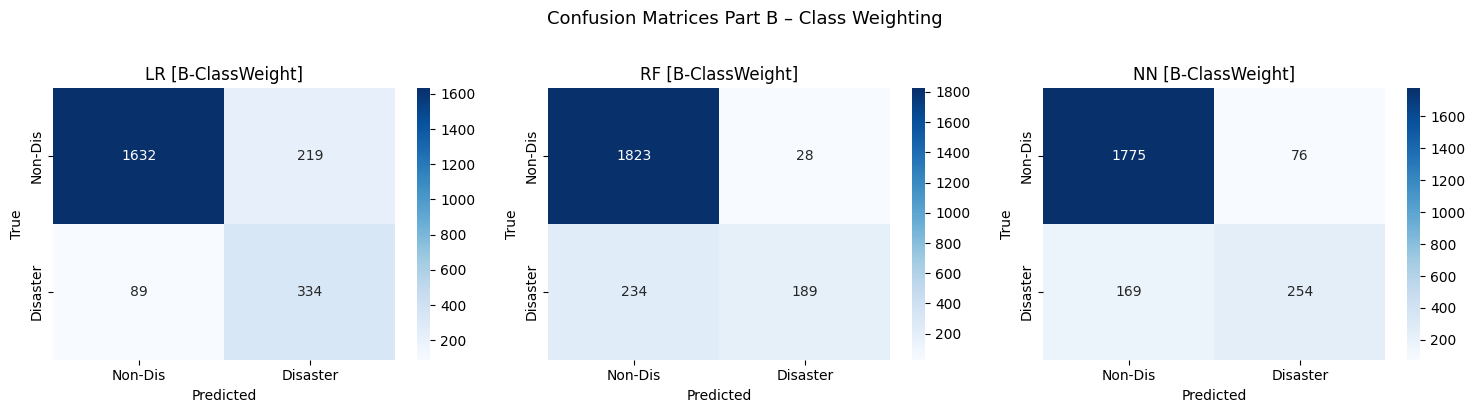

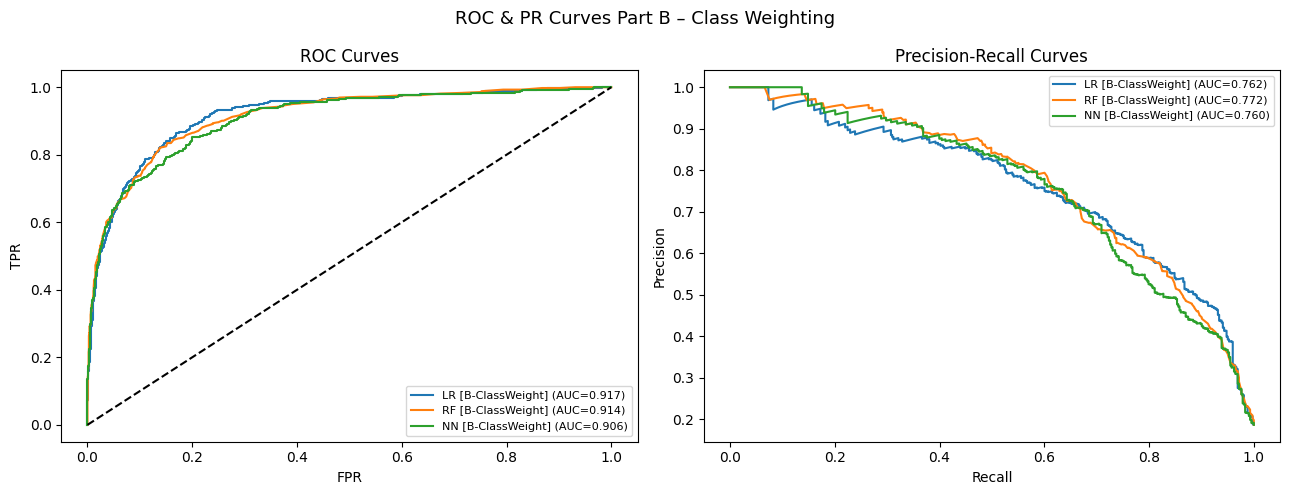

In [53]:
# Class weighting
results_b_cw = [res_lr_cw, res_rf_cw, res_nn_cw]
plot_confusion_matrix(results_b_cw, 'Part B – Class Weighting')
plot_roc_pr(results_b_cw, 'Part B – Class Weighting')


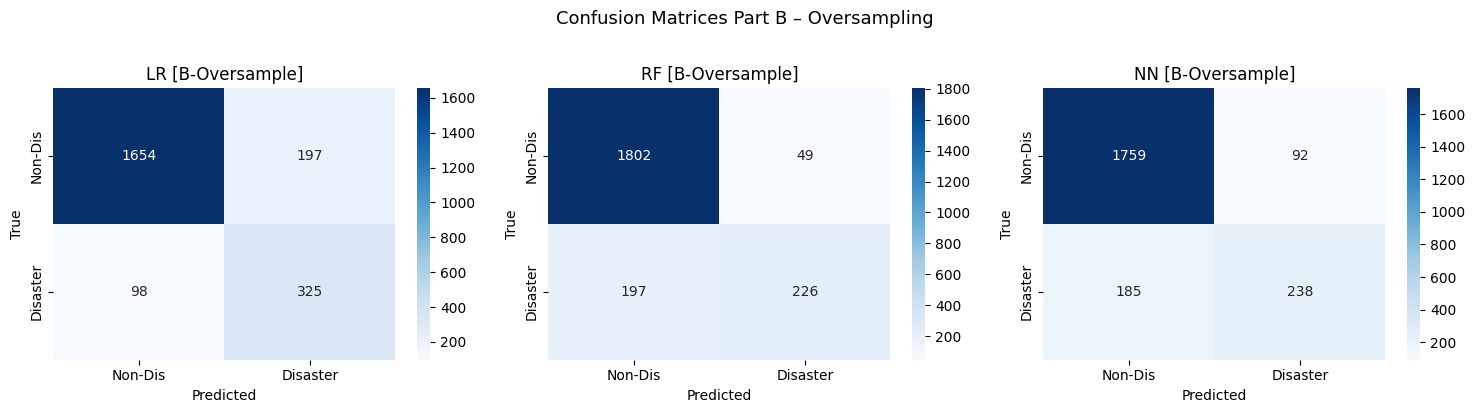

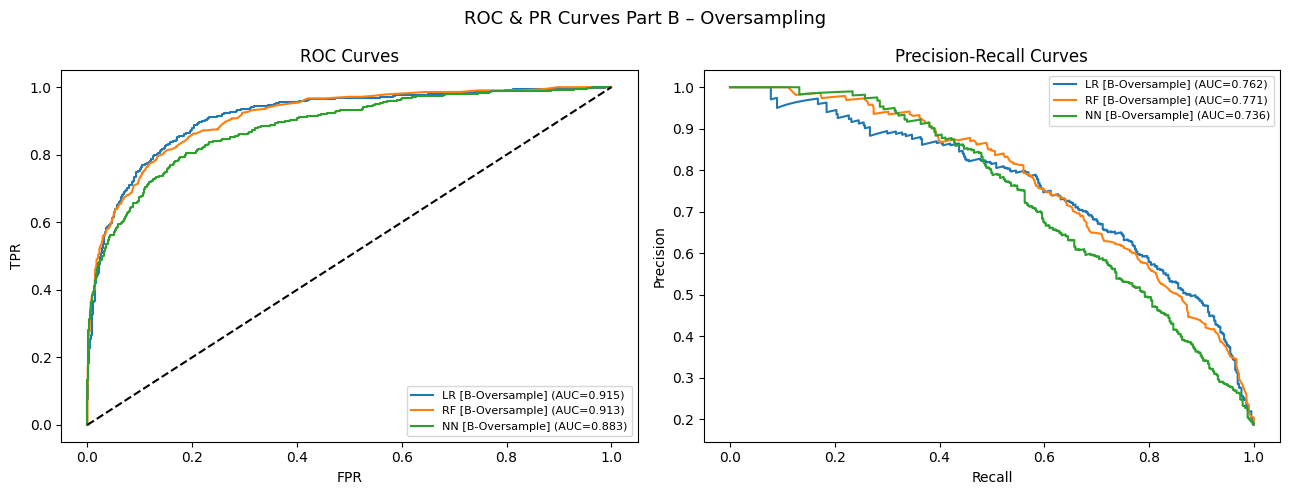

In [54]:
# Oversampling
results_b_os = [res_lr_os, res_rf_os, res_nn_os]
plot_confusion_matrix(results_b_os, 'Part B – Oversampling')
plot_roc_pr(results_b_os, 'Part B – Oversampling')


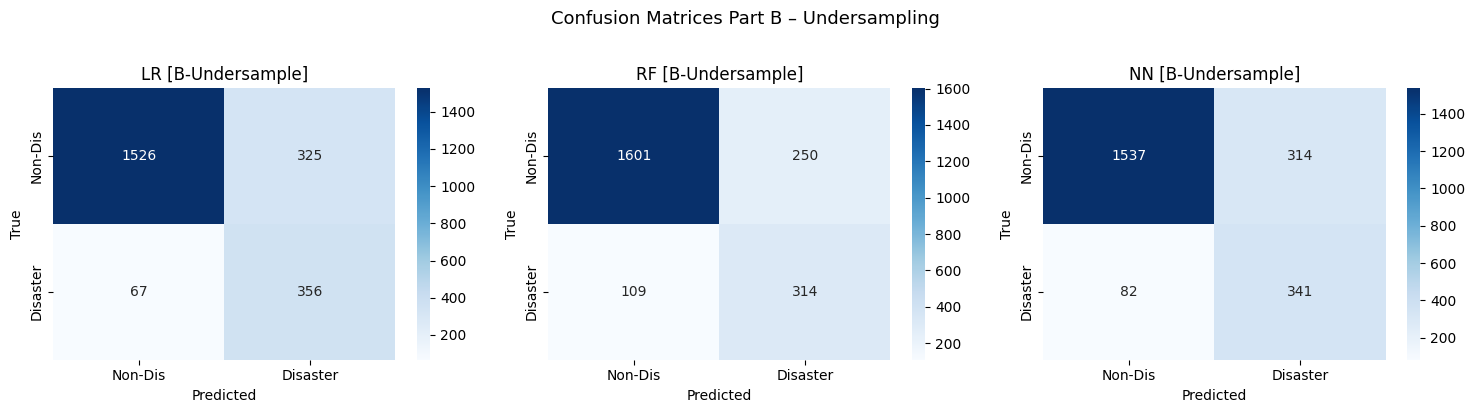

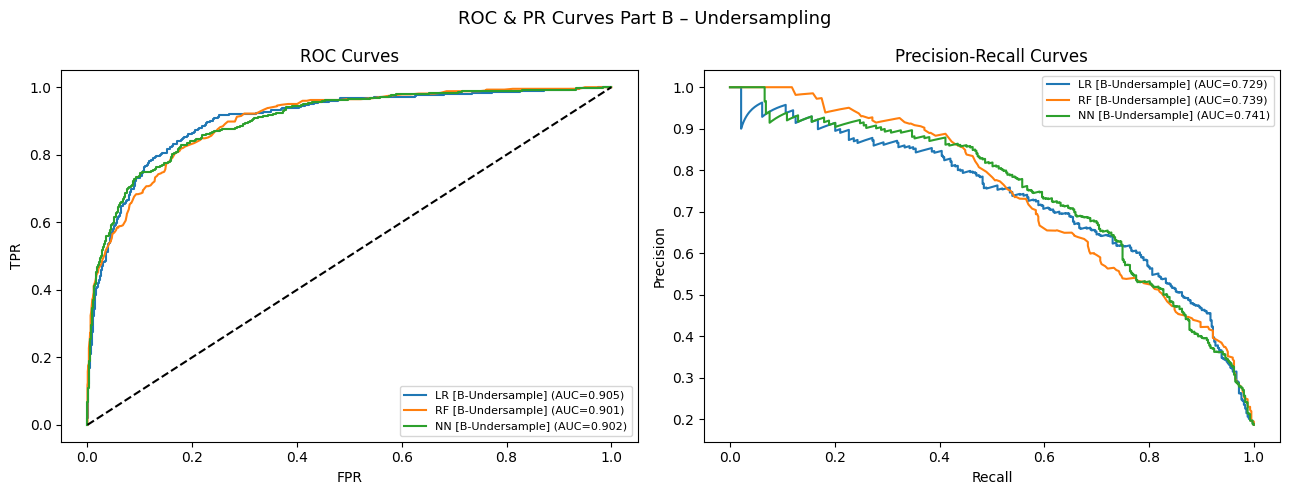

In [55]:
# Undersampling
results_b_us = [res_lr_us, res_rf_us, res_nn_us]
plot_confusion_matrix(results_b_us, 'Part B – Undersampling')
plot_roc_pr(results_b_us, 'Part B – Undersampling')


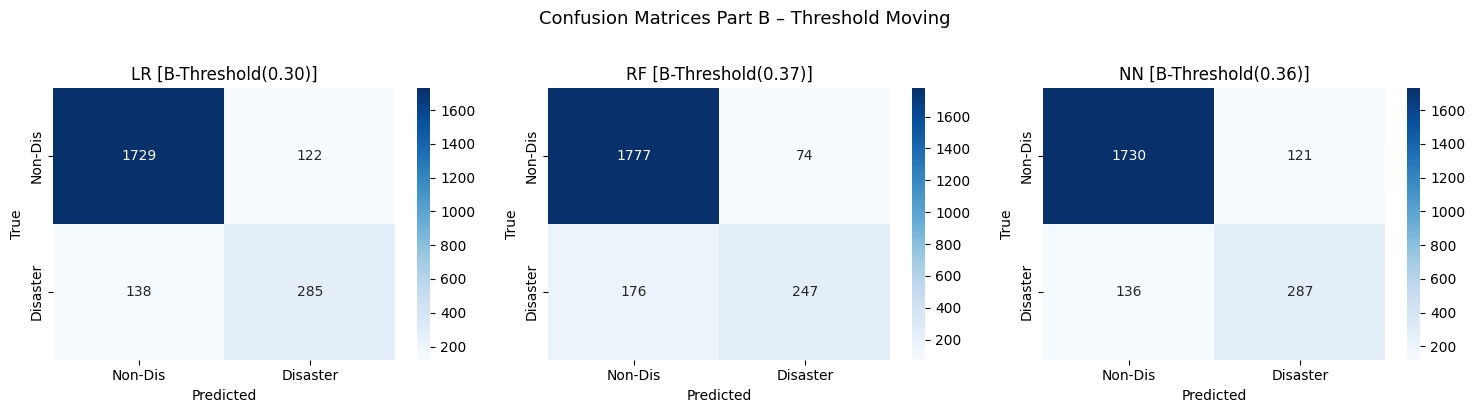

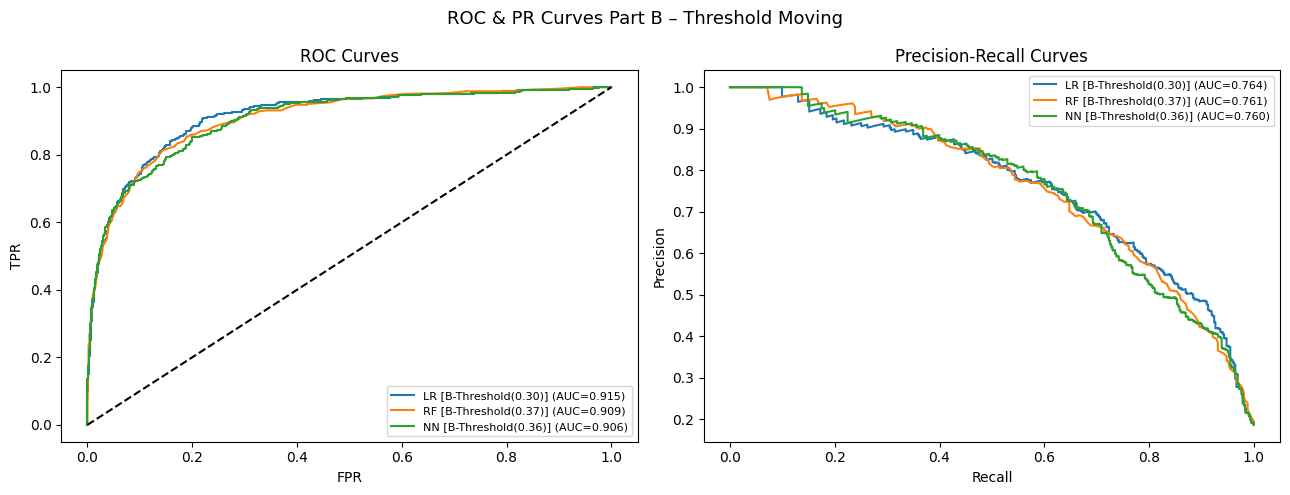

In [56]:
# Threshold moving
results_b_th = [res_lr_th, res_rf_th, res_nn_th]
plot_confusion_matrix(results_b_th, 'Part B – Threshold Moving')
plot_roc_pr(results_b_th, 'Part B – Threshold Moving')


## 7. Master Comparison Table – All Experiments

In [57]:
all_results = (
    [res_lr_a, res_rf_a, res_nn_a]
  + results_b_cw
  + results_b_os
  + results_b_us
  + results_b_th
)

cols = ['Model', 'Accuracy', 'F1 Macro', 'F1 Weighted', 'ROC-AUC', 'PR-AUC']
master_df = pd.DataFrame([
    {k: v for k, v in r.items() if k in cols}
    for r in all_results
]).set_index('Model').round(4)

print(master_df.to_string())
master_df


                              Accuracy  F1 Macro  F1 Weighted  ROC-AUC  PR-AUC
Model                                                                         
Logistic Regression [Part A]    0.8729    0.7230       0.8510   0.9145  0.7644
Random Forest [Part A]          0.8835    0.7619       0.8687   0.9089  0.7605
Neural Network [Part A]         0.8923    0.8050       0.8869   0.9061  0.7596
LR [B-ClassWeight]              0.8646    0.7991       0.8711   0.9175  0.7623
RF [B-ClassWeight]              0.8848    0.7618       0.8693   0.9140  0.7721
NN [B-ClassWeight]              0.8923    0.8050       0.8869   0.9061  0.7596
LR [B-Oversample]               0.8703    0.8030       0.8753   0.9154  0.7617
RF [B-Oversample]               0.8918    0.7918       0.8824   0.9126  0.7710
NN [B-Oversample]               0.8782    0.7796       0.8722   0.8831  0.7356
LR [B-Undersample]              0.8276    0.7656       0.8413   0.9051  0.7292
RF [B-Undersample]              0.8421    0.7677    

,Accuracy,F1 Macro,F1 Weighted,ROC-AUC,PR-AUC
Model,,,,,
Logistic Regression [Part A],0.8729,0.7230,0.8510,0.9145,0.7644
Random Forest [Part A],0.8835,0.7619,0.8687,0.9089,0.7605
Neural Network [Part A],0.8923,0.8050,0.8869,0.9061,0.7596
LR [B-ClassWeight],0.8646,0.7991,0.8711,0.9175,0.7623
RF [B-ClassWeight],0.8848,0.7618,0.8693,0.9140,0.7721
NN [B-ClassWeight],0.8923,0.8050,0.8869,0.9061,0.7596
LR [B-Oversample],0.8703,0.8030,0.8753,0.9154,0.7617
RF [B-Oversample],0.8918,0.7918,0.8824,0.9126,0.7710
NN [B-Oversample],0.8782,0.7796,0.8722,0.8831,0.7356


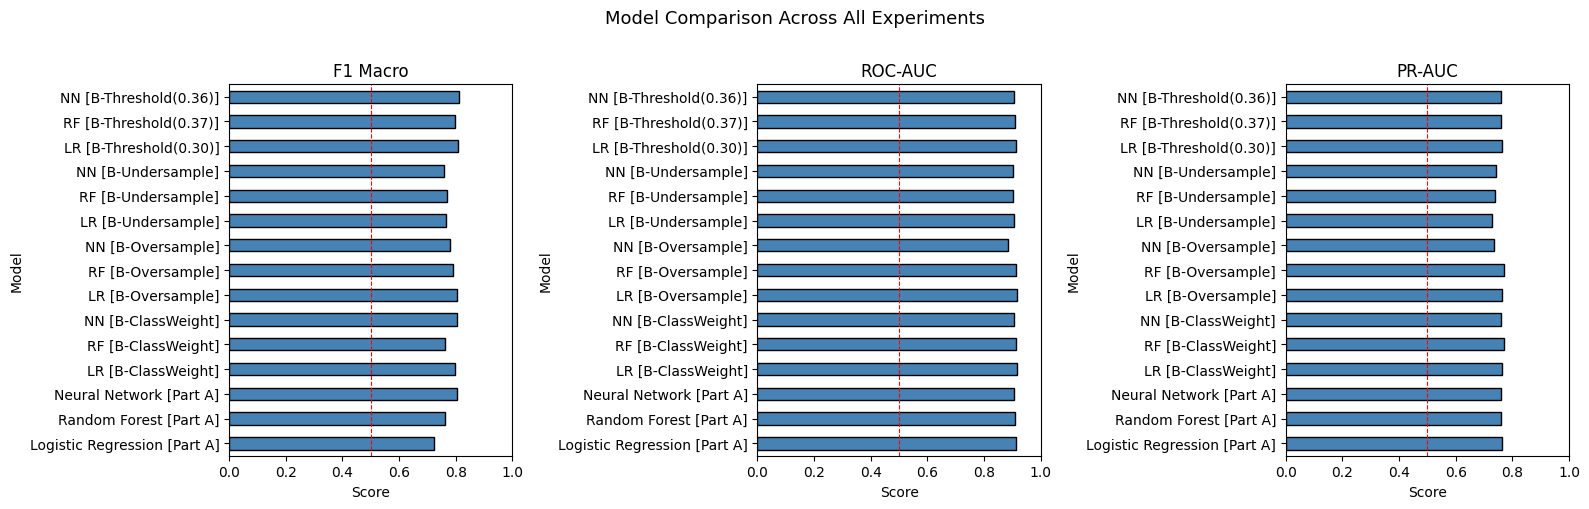

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = ['F1 Macro', 'ROC-AUC', 'PR-AUC']

for ax, metric in zip(axes, metrics_to_plot):
    master_df[metric].plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(metric)
    ax.set_xlim(0, 1)
    ax.axvline(0.5, color='red', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Score')

plt.suptitle('Model Comparison Across All Experiments', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('master_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Analysis & Conclusion

### Key Observations
1. **Part A (no handling):** Models achieve high accuracy but lower recall on the minority (Disaster) class,    which is the more important class in disaster detection. This reflects the impact of class imbalance.

2. **Class Weighting:** A simple and effective technique. Boosts minority recall with minimal additional cost.    Recommended as a first-line approach for all three models.

3. **Random Oversampling:** Equalises class distribution by duplicating minority samples.    Improves F1-Macro but may cause overfitting since no new information is added.

4. **Random Undersampling:** Reduces training data size, which can hurt performance for smaller datasets.    Best suited when the majority class is extremely large.

5. **Threshold Moving:** Adjusts the decision boundary post-training. Works well in combination with    class weighting; particularly useful when models need to be retrained infrequently.

### Best Performing Configuration
- Refer to the **Master Comparison Table** above to identify the configuration with highest F1 Macro and PR-AUC.
- Generally, **Logistic Regression + Class Weighting** or **Neural Network + Oversampling** tend to perform well on tweet datasets.

### Model Complexity Trade-offs
| Model | Training Speed | Interpretability | Performance |
|---|---|---|---|
| Logistic Regression | Fast | High | Good baseline |
| Random Forest | Medium | Medium | Robust, handles noise |
| Neural Network | Slow | Low | Highest potential with tuning |
